# Online Retail II — Funnel, Cohort & AARRR Analysis

**Dataset**: [Online Retail II (UCI)](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — ~1M transactions from a UK-based online retailer (Dec 2009 – Dec 2011)

**Objective**: Analyze customer purchasing behavior using funnel analysis, cohort-based retention, and the AARRR framework to derive actionable business insights.

## Table of Contents
1. [Data Loading & Preprocessing](#1-data-loading--preprocessing)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis-eda)
3. [Customer Engagement Funnel](#3-customer-engagement-funnel)
4. [Cohort Analysis](#4-cohort-analysis)
5. [AARRR Pirate Metrics](#5-aarrr-pirate-metrics)
6. [Key Insights & Recommendations](#6-key-insights--recommendations)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 5)

IMAGES_DIR = Path('../images')
IMAGES_DIR.mkdir(exist_ok=True)

---
## 1. Data Loading & Preprocessing

In [2]:
# Load both sheets and merge
sheet1 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
sheet2 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2010-2011')
raw = pd.concat([sheet1, sheet2], ignore_index=True)

print(f'Raw data shape: {raw.shape}')
raw.head()

Raw data shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print('--- Data Types ---')
print(raw.dtypes)
print(f'\n--- Missing Values ---')
print(raw.isnull().sum())
print(f'\nMissing Customer ID: {raw["Customer ID"].isnull().mean():.1%}')
print(f'\nColumns: {list(raw.columns)}')

--- Data Types ---
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

--- Missing Values ---


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Missing Customer ID: 22.8%

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [4]:
df = raw.copy()

# 1. Drop missing Customer ID
df = df.dropna(subset=['Customer ID'])

# 2. Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 3. Remove non-positive Quantity and Price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 4. Feature engineering
df['Revenue'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['InvoiceYearMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
df['Customer ID'] = df['Customer ID'].astype(int)

print(f'Cleaned data shape: {df.shape}')
print(f'Date range: {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}')
print(f'Unique customers: {df["Customer ID"].nunique():,}')
print(f'Unique invoices: {df["Invoice"].nunique():,}')
print(f'Total revenue: £{df["Revenue"].sum():,.0f}')
df.head()

Cleaned data shape: (805549, 11)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5,878
Unique invoices: 36,969
Total revenue: £17,743,429


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,InvoiceMonth,InvoiceYearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12-01


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Monthly Revenue Trend

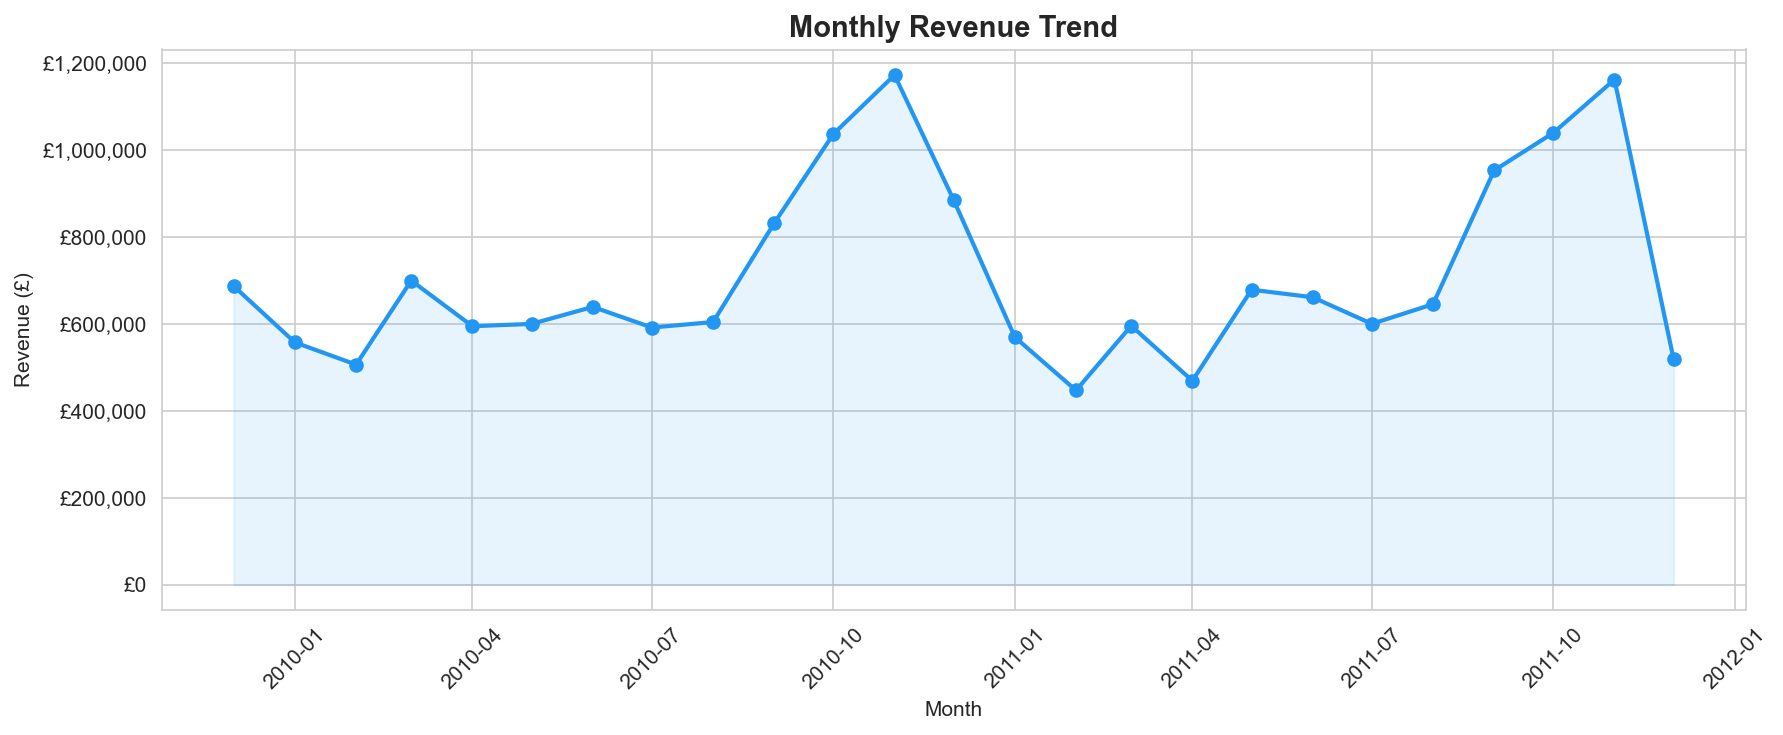

In [5]:
monthly_revenue = df.groupby('InvoiceYearMonth')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2, color='#2196F3')
ax.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.1, color='#2196F3')
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '01_monthly_revenue.png', bbox_inches='tight')
plt.show()

### 2.2 Monthly Unique Customers

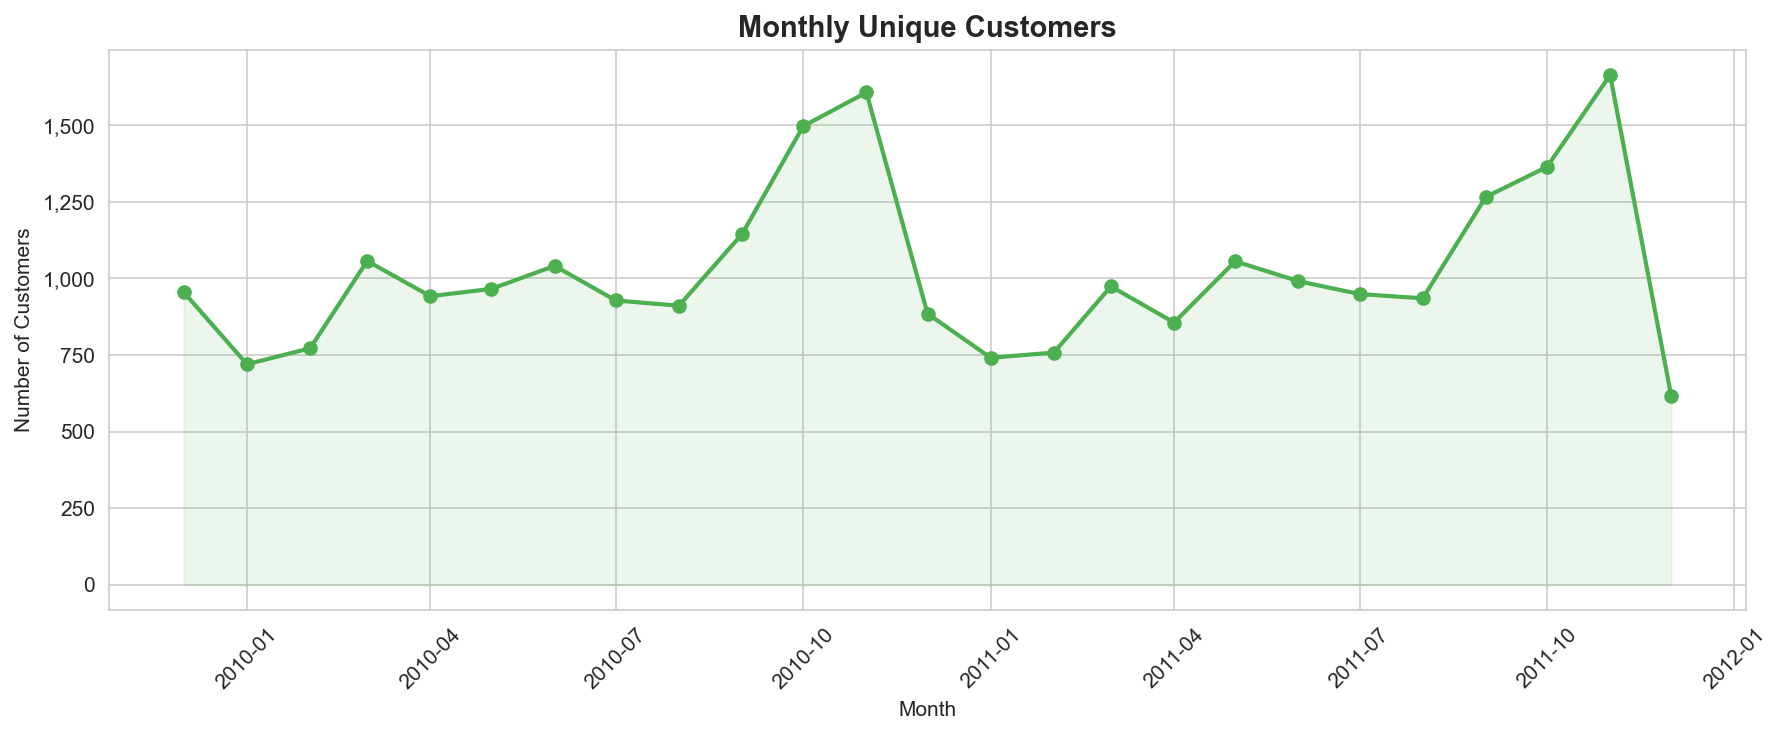

In [6]:
monthly_customers = df.groupby('InvoiceYearMonth')['Customer ID'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_customers.index, monthly_customers.values, marker='o', linewidth=2, color='#4CAF50')
ax.fill_between(monthly_customers.index, monthly_customers.values, alpha=0.1, color='#4CAF50')
ax.set_title('Monthly Unique Customers', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '02_monthly_customers.png', bbox_inches='tight')
plt.show()

### 2.3 Top 10 Countries by Revenue

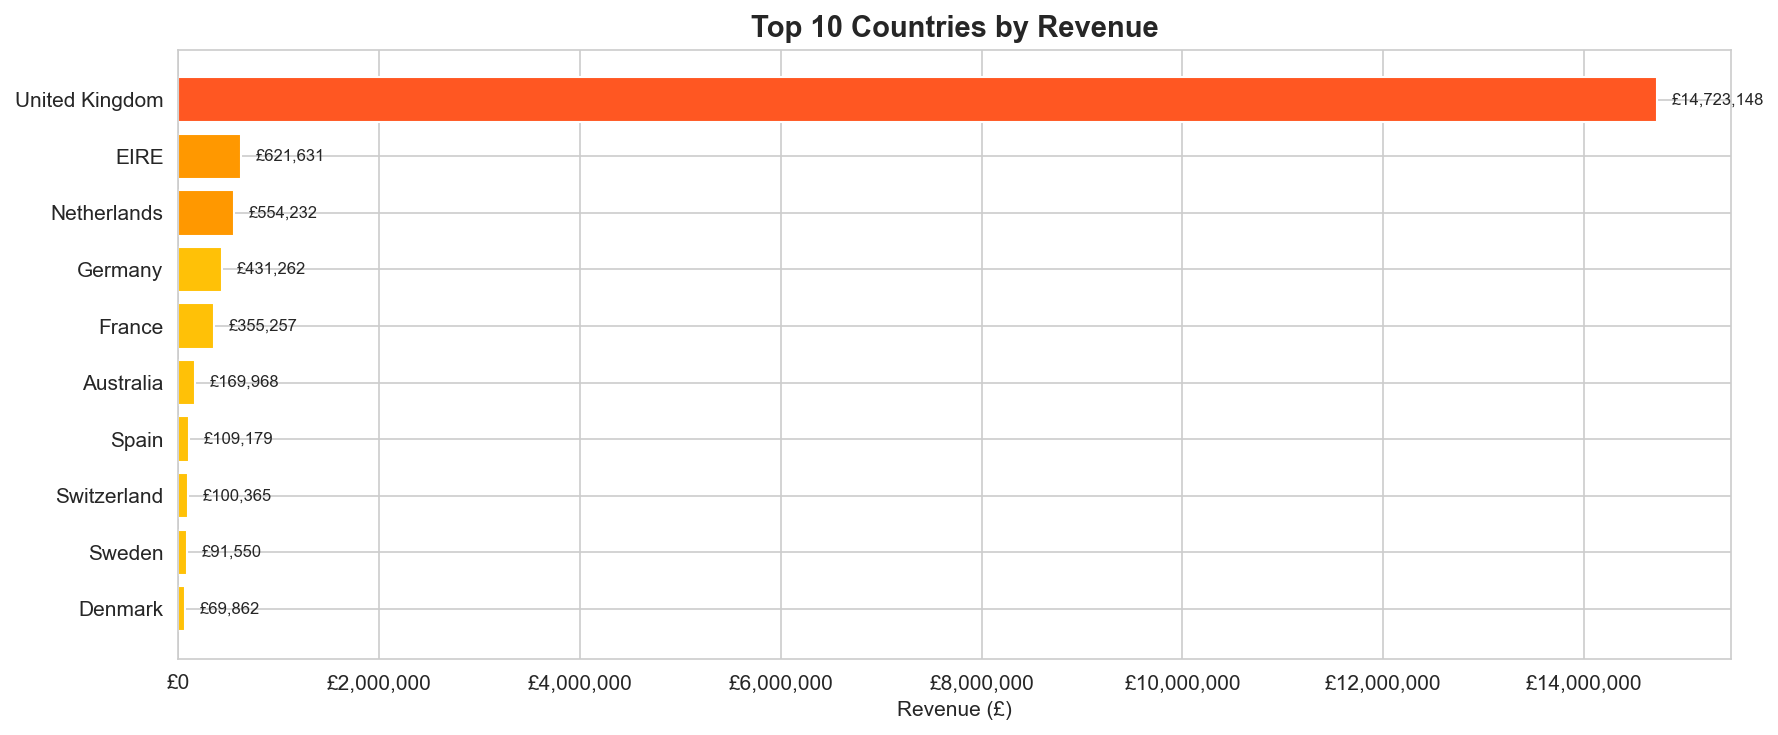


UK share of total revenue: 83.0%


In [7]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
top10 = country_revenue.head(10)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#FF5722' if i == 0 else '#FF9800' if i < 3 else '#FFC107' for i in range(len(top10))]
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(val + country_revenue.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '03_top10_countries.png', bbox_inches='tight')
plt.show()

print(f'\nUK share of total revenue: {country_revenue["United Kingdom"] / country_revenue.sum():.1%}')

### 2.4 Order Frequency Distribution

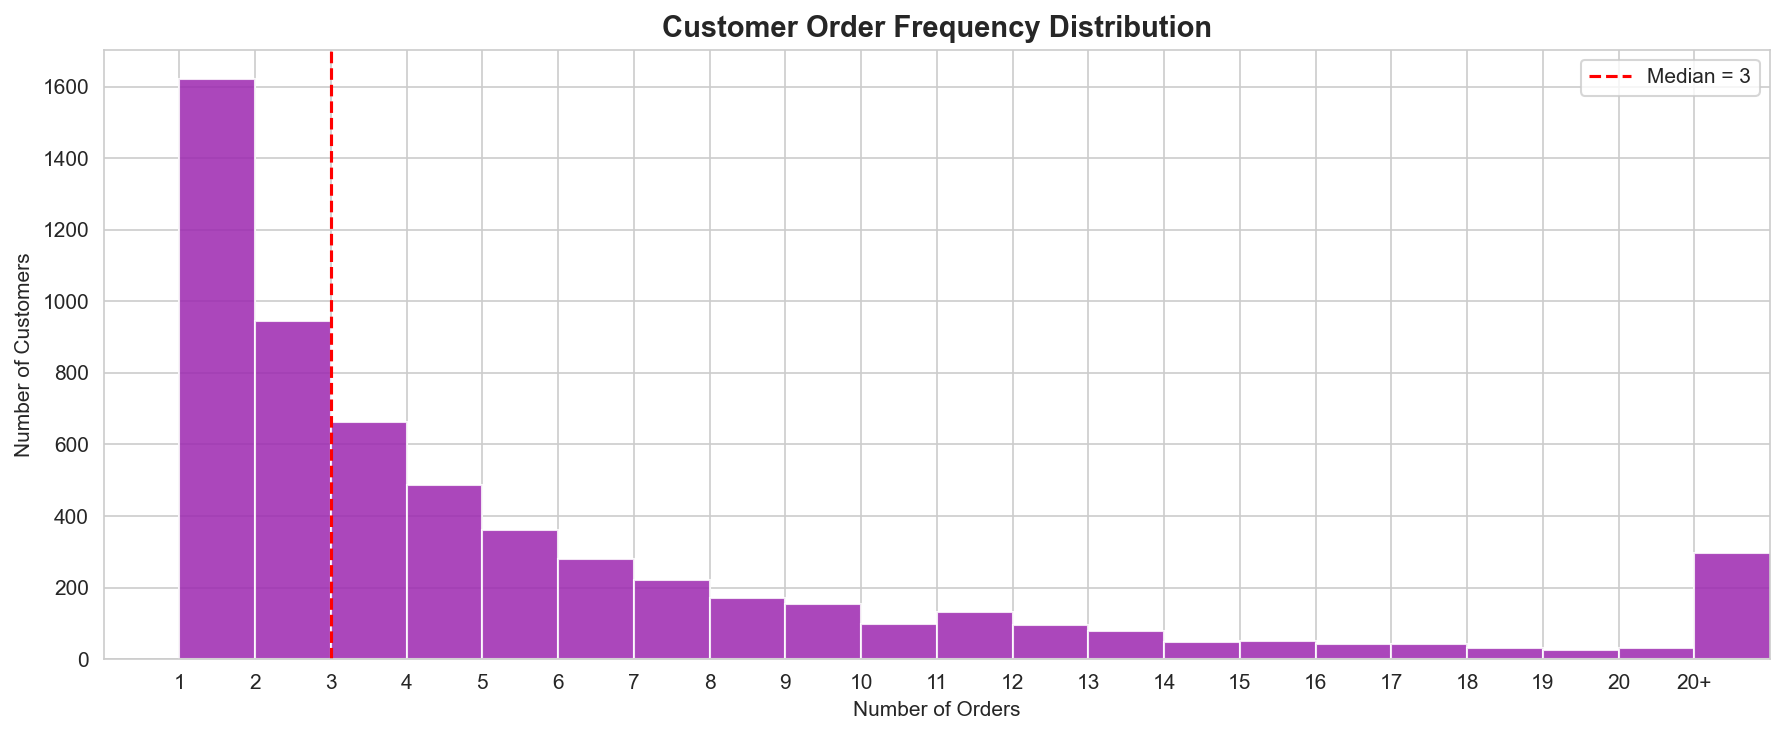

Mean orders per customer: 6.3
Median orders per customer: 3
Customers with only 1 order: 1,623 (27.6%)


In [8]:
customer_orders = df.groupby('Customer ID')['Invoice'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
bins = list(range(1, 22)) + [customer_orders.max() + 1]
ax.hist(customer_orders.values, bins=bins, color='#9C27B0', edgecolor='white', alpha=0.85)
ax.set_title('Customer Order Frequency Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
ax.set_xlim(0, 22)
ax.set_xticks(range(1, 22))
labels = [str(i) for i in range(1, 21)] + ['20+']
ax.set_xticklabels(labels)

median_orders = customer_orders.median()
ax.axvline(median_orders, color='red', linestyle='--', linewidth=1.5, label=f'Median = {median_orders:.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '04_order_frequency.png', bbox_inches='tight')
plt.show()

print(f'Mean orders per customer: {customer_orders.mean():.1f}')
print(f'Median orders per customer: {customer_orders.median():.0f}')
print(f'Customers with only 1 order: {(customer_orders == 1).sum():,} ({(customer_orders == 1).mean():.1%})')

### 2.5 Revenue Concentration (Pareto)

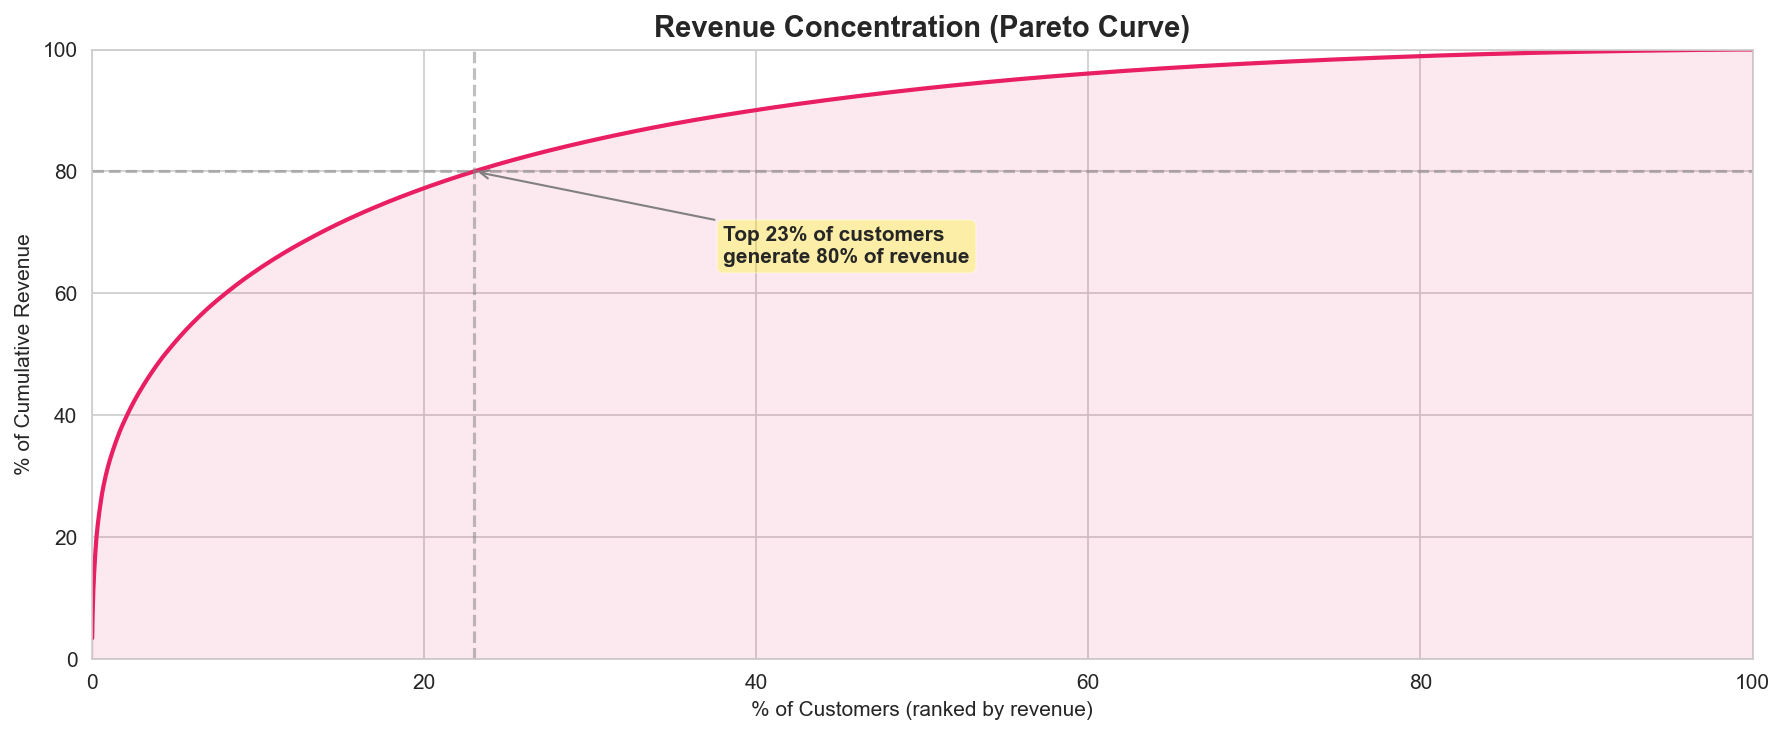

In [9]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
cumulative_pct = customer_revenue.cumsum() / customer_revenue.sum() * 100
customer_pct = np.arange(1, len(cumulative_pct) + 1) / len(cumulative_pct) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(customer_pct, cumulative_pct.values, color='#E91E63', linewidth=2)
ax.fill_between(customer_pct, cumulative_pct.values, alpha=0.1, color='#E91E63')

# Find 80% revenue point
idx_80 = np.searchsorted(cumulative_pct.values, 80)
pct_80 = customer_pct[idx_80]
ax.axhline(80, color='gray', linestyle='--', alpha=0.5)
ax.axvline(pct_80, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'Top {pct_80:.0f}% of customers\ngenerate 80% of revenue',
            xy=(pct_80, 80), xytext=(pct_80 + 15, 65),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='gray'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_title('Revenue Concentration (Pareto Curve)', fontsize=14, fontweight='bold')
ax.set_xlabel('% of Customers (ranked by revenue)')
ax.set_ylabel('% of Cumulative Revenue')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '05_pareto.png', bbox_inches='tight')
plt.show()

---
## 3. Customer Engagement Funnel

Since web-level funnel data (visit → add to cart → checkout) is not available, we define a **Customer Engagement Funnel** based on purchasing behavior:

| Stage | Definition |
|---|---|
| All Customers | At least 1 purchase |
| Repeat Buyers | 2+ separate orders |
| Regular Buyers | Active in 3+ distinct months |
| High-Value | Top 25% by total revenue |
| Loyal High-Value | Top 25% revenue AND active 3+ months |

In [10]:
# Build per-customer metrics
cust = df.groupby('Customer ID').agg(
    n_orders=('Invoice', 'nunique'),
    n_months=('InvoiceMonth', 'nunique'),
    total_revenue=('Revenue', 'sum')
).reset_index()

revenue_75th = cust['total_revenue'].quantile(0.75)

funnel = {
    'All Customers': len(cust),
    'Repeat Buyers (2+ orders)': (cust['n_orders'] >= 2).sum(),
    'Regular Buyers (3+ months)': (cust['n_months'] >= 3).sum(),
    'High-Value (top 25% revenue)': (cust['total_revenue'] >= revenue_75th).sum(),
    'Loyal High-Value': ((cust['total_revenue'] >= revenue_75th) & (cust['n_months'] >= 3)).sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=['Stage', 'Customers'])
funnel_df['% of Total'] = (funnel_df['Customers'] / funnel_df['Customers'].iloc[0] * 100).round(1)
funnel_df['Conversion'] = ['-'] + [
    f"{funnel_df['Customers'].iloc[i] / funnel_df['Customers'].iloc[i-1] * 100:.1f}%"
    for i in range(1, len(funnel_df))
]

print(funnel_df.to_string(index=False))

                       Stage  Customers  % of Total Conversion
               All Customers       5878       100.0          -
   Repeat Buyers (2+ orders)       4255        72.4      72.4%
  Regular Buyers (3+ months)       3030        51.5      71.2%
High-Value (top 25% revenue)       1470        25.0      48.5%
            Loyal High-Value       1404        23.9      95.5%


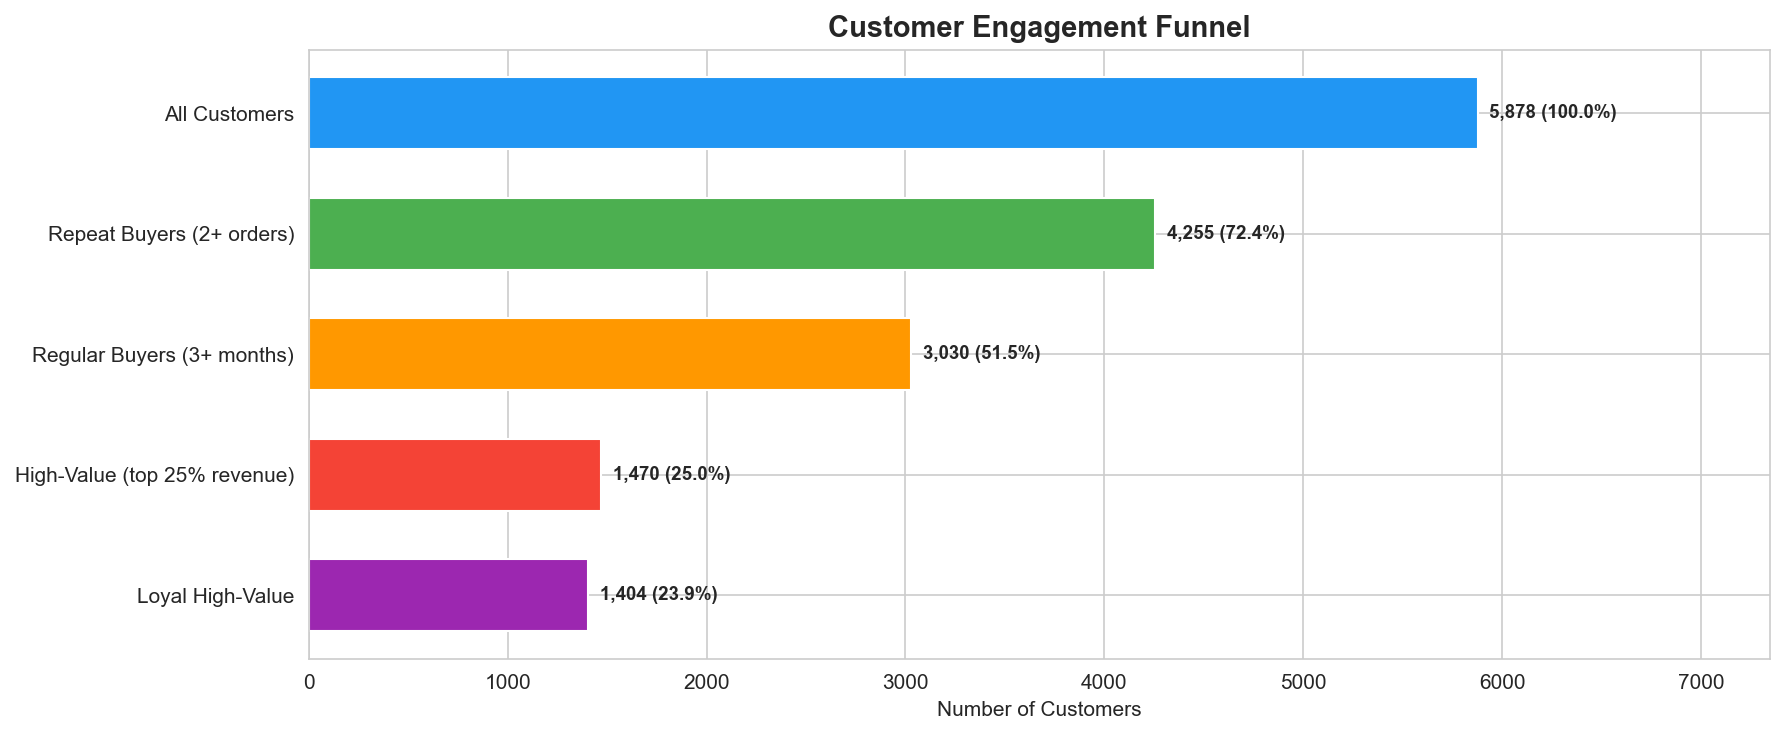

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
y_pos = range(len(funnel_df) - 1, -1, -1)

bars = ax.barh(y_pos, funnel_df['Customers'], color=colors, edgecolor='white', height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(funnel_df['Stage'])
ax.set_title('Customer Engagement Funnel', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Customers')

for bar, customers, pct in zip(bars, funnel_df['Customers'], funnel_df['% of Total']):
    ax.text(bar.get_width() + funnel_df['Customers'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{customers:,} ({pct}%)', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, funnel_df['Customers'].max() * 1.25)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '06_funnel.png', bbox_inches='tight')
plt.show()

---
## 4. Cohort Analysis

In [12]:
# Assign each customer to their first purchase month (cohort)
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceYearMonth'].transform('min')

# Calculate cohort index (months since first purchase)
df['CohortIndex'] = ((df['InvoiceYearMonth'].dt.year - df['CohortMonth'].dt.year) * 12 +
                      (df['InvoiceYearMonth'].dt.month - df['CohortMonth'].dt.month))

# Build cohort table: count unique customers per (CohortMonth, CohortIndex)
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Retention rate: divide each column by the first column (month 0)
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

print(f'Number of cohorts: {len(retention)}')
print(f'Cohort range: {retention.index.min()} to {retention.index.max()}')
retention.head()

Number of cohorts: 25
Cohort range: 2009-12-01 00:00:00 to 2011-12-01 00:00:00


CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12-01,100.0,35.287958,33.403141,42.513089,38.010471,35.916230,37.696335,34.240838,33.612565,36.230366,...,30.261780,26.282723,30.261780,28.272251,25.968586,25.549738,31.518325,30.471204,40.732984,19.685864
2010-01-01,100.0,20.626632,31.070496,30.548303,26.370757,30.026110,25.848564,22.976501,27.937337,31.853786,...,15.143603,23.498695,19.843342,18.537859,19.582245,24.281984,19.321149,24.543081,5.744125,NaN
2010-02-01,100.0,23.796791,22.459893,29.144385,24.598930,20.053476,19.251337,28.609626,25.401070,27.540107,...,20.053476,16.042781,16.310160,14.438503,22.994652,22.994652,16.310160,5.882353,NaN,NaN
2010-03-01,100.0,18.961625,23.024831,24.153499,23.250564,20.316027,24.604966,30.248307,27.539503,10.835214,...,16.930023,17.381490,15.575621,17.607223,20.090293,21.218962,7.900677,NaN,NaN,NaN
2010-04-01,100.0,19.387755,19.387755,16.326531,18.367347,22.448980,27.551020,26.190476,10.544218,10.884354,...,15.646259,13.945578,14.965986,18.027211,22.448980,5.782313,NaN,NaN,NaN,NaN


### 4.1 Retention Heatmap

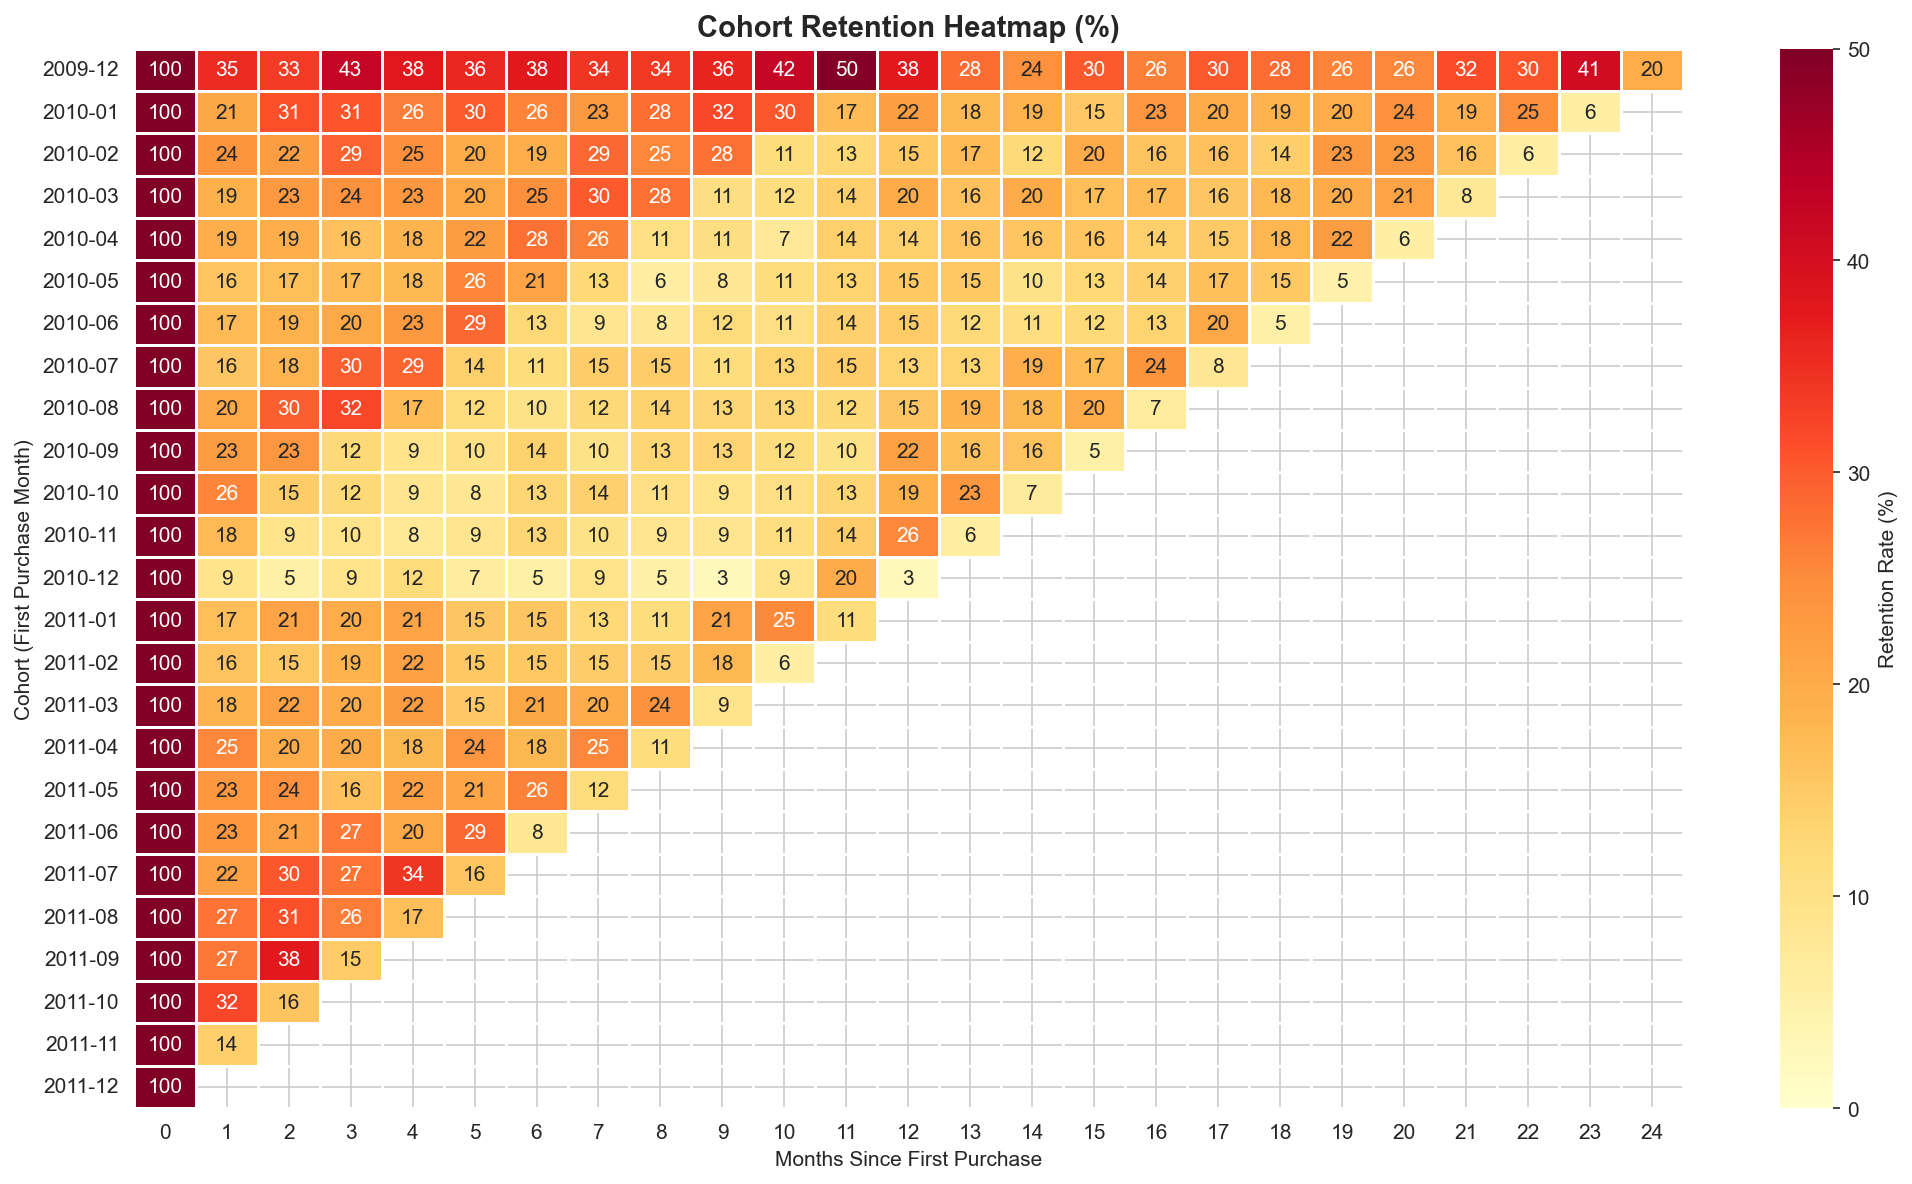

In [13]:
fig, ax = plt.subplots(figsize=(14, 8))

# Format index for display
retention_display = retention.copy()
retention_display.index = retention_display.index.strftime('%Y-%m')

sns.heatmap(retention_display, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=50,
            cbar_kws={'label': 'Retention Rate (%)'})

ax.set_title('Cohort Retention Heatmap (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '07_cohort_heatmap.png', bbox_inches='tight')
plt.show()

### 4.2 Cohort Size

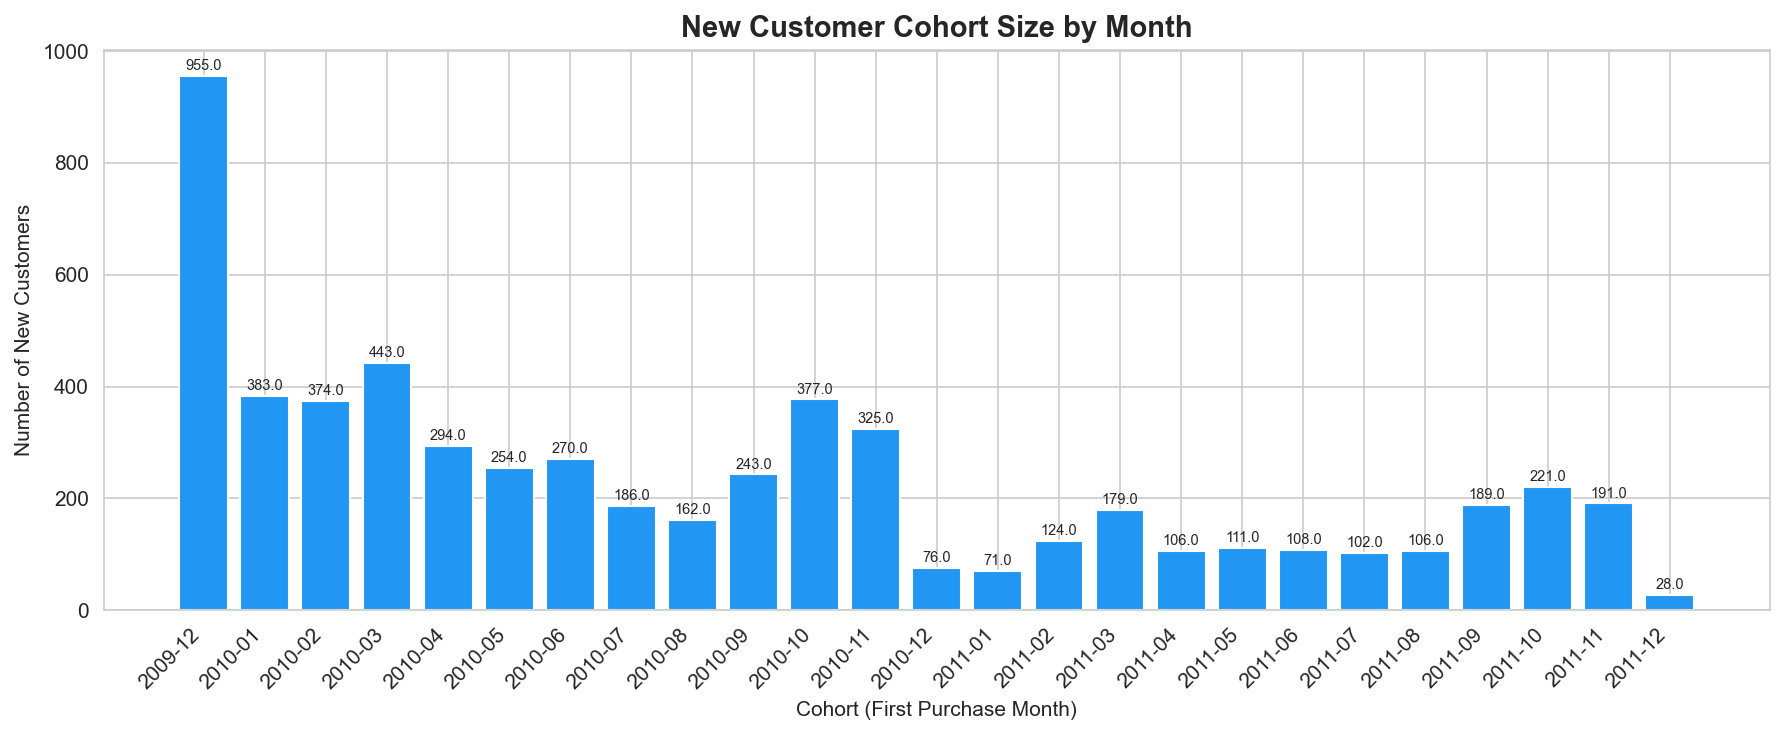

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

cohort_labels = cohort_size.index.strftime('%Y-%m')
bars = ax.bar(cohort_labels, cohort_size.values, color='#2196F3', edgecolor='white')
ax.set_title('New Customer Cohort Size by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Cohort (First Purchase Month)')
ax.set_ylabel('Number of New Customers')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, cohort_size.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '08_cohort_size.png', bbox_inches='tight')
plt.show()

### 4.3 Average Retention Curve

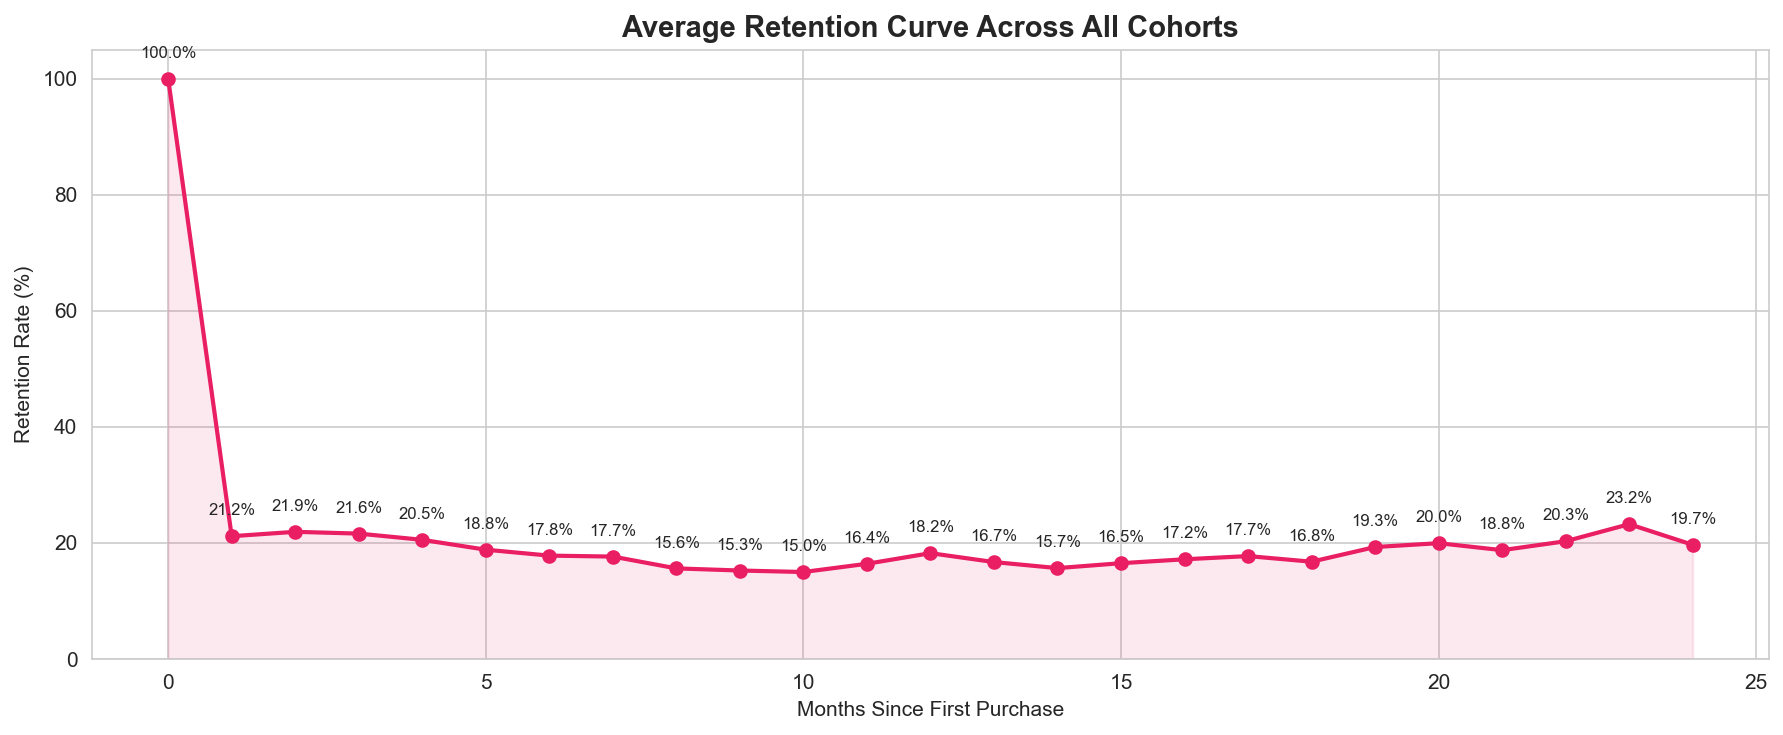

Month 1 avg retention: 21.2%
Month 3 avg retention: 21.6%
Month 6 avg retention: 17.8%
Month 12 avg retention: 18.2%


In [15]:
avg_retention = retention.mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_retention.index, avg_retention.values, marker='o', linewidth=2, color='#E91E63')
ax.fill_between(avg_retention.index, avg_retention.values, alpha=0.1, color='#E91E63')

for i, (x, y) in enumerate(zip(avg_retention.index, avg_retention.values)):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8)

ax.set_title('Average Retention Curve Across All Cohorts', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Retention Rate (%)')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '09_avg_retention.png', bbox_inches='tight')
plt.show()

print(f'Month 1 avg retention: {avg_retention.iloc[1]:.1f}%')
print(f'Month 3 avg retention: {avg_retention.iloc[3]:.1f}%' if len(avg_retention) > 3 else '')
print(f'Month 6 avg retention: {avg_retention.iloc[6]:.1f}%' if len(avg_retention) > 6 else '')
print(f'Month 12 avg retention: {avg_retention.iloc[12]:.1f}%' if len(avg_retention) > 12 else '')

---
## 5. AARRR Pirate Metrics

### 5.1 Acquisition — Monthly New Customers

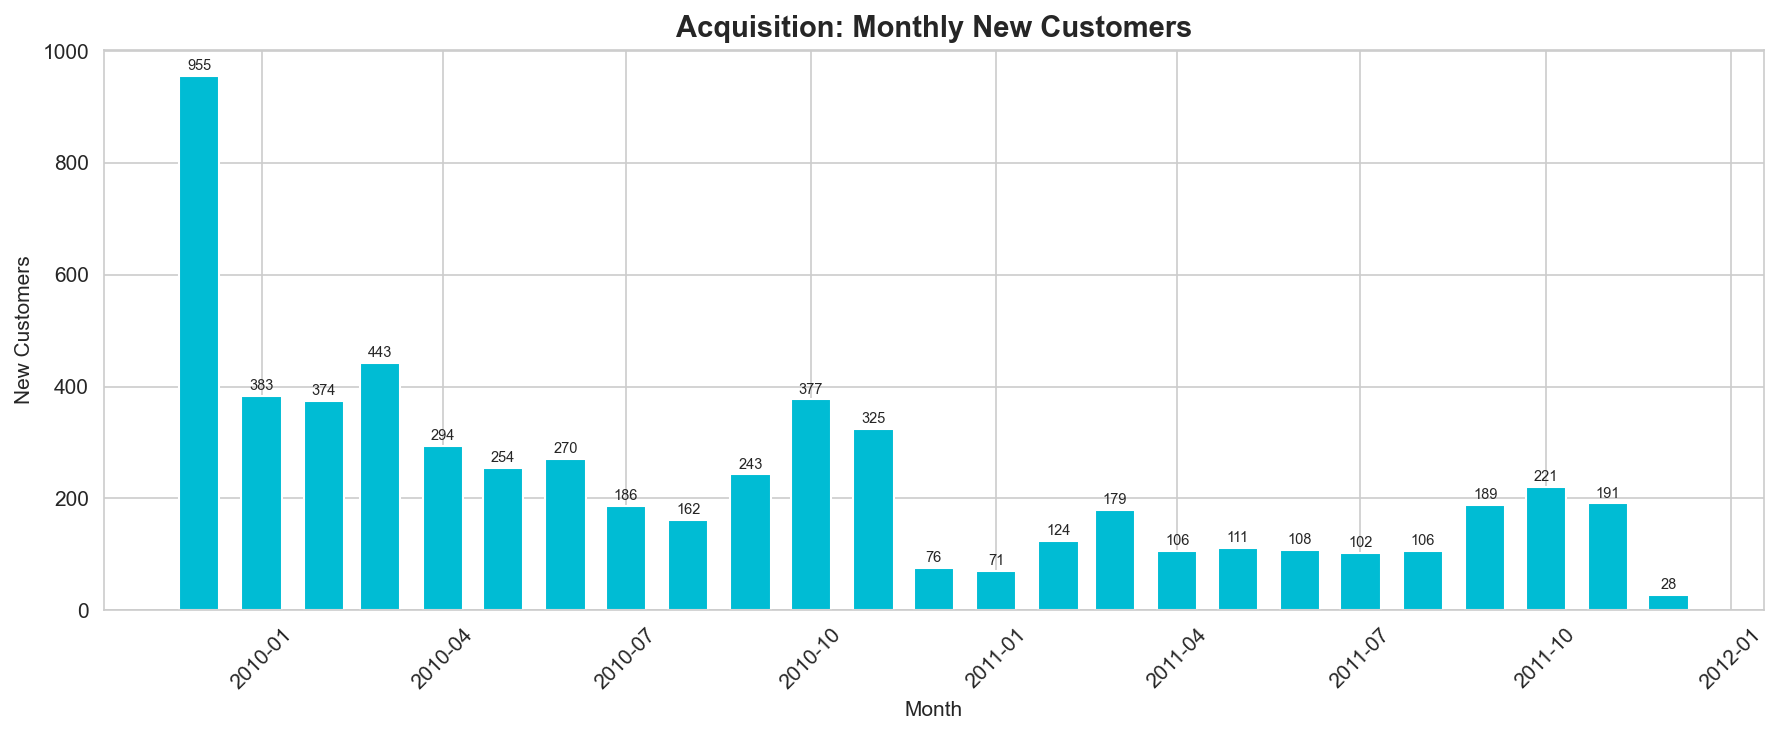

Total unique customers acquired: 5,878
Average new customers per month: 235


In [16]:
first_purchase = df.groupby('Customer ID')['InvoiceYearMonth'].min().reset_index()
first_purchase.columns = ['Customer ID', 'FirstPurchaseMonth']
new_customers = first_purchase.groupby('FirstPurchaseMonth').size()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(new_customers.index, new_customers.values, color='#00BCD4', edgecolor='white', width=20)
ax.set_title('Acquisition: Monthly New Customers', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('New Customers')
plt.xticks(rotation=45)

for bar, val in zip(bars, new_customers.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '10_acquisition.png', bbox_inches='tight')
plt.show()

print(f'Total unique customers acquired: {len(first_purchase):,}')
print(f'Average new customers per month: {new_customers.mean():.0f}')

### 5.2 Activation — First Order Quality

In [17]:
# Get each customer's first invoice
first_invoice = df.sort_values('InvoiceDate').groupby('Customer ID').first().reset_index()

# Merge to get all items from first order
first_orders = df.merge(
    first_invoice[['Customer ID', 'Invoice']],
    on=['Customer ID', 'Invoice'],
    how='inner'
)

first_order_revenue = first_orders.groupby('Customer ID')['Revenue'].sum()
first_order_items = first_orders.groupby('Customer ID')['Quantity'].sum()

print('=== Activation Metrics: First Order Quality ===')
print(f'Average first order value: £{first_order_revenue.mean():.2f}')
print(f'Median first order value: £{first_order_revenue.median():.2f}')
print(f'Average items in first order: {first_order_items.mean():.1f}')
print(f'Median items in first order: {first_order_items.median():.0f}')

# What % of first-time buyers return?
repeat_rate = (cust['n_orders'] >= 2).mean()
print(f'\nFirst → Repeat conversion rate: {repeat_rate:.1%}')

=== Activation Metrics: First Order Quality ===
Average first order value: £416.30
Median first order value: £298.31
Average items in first order: 262.0
Median items in first order: 156

First → Repeat conversion rate: 72.4%


### 5.3 Retention — 30/60/90-day Repurchase Rate

In [18]:
# Calculate days between first and second purchase for each customer
customer_dates = df.groupby('Customer ID')['InvoiceDate'].agg(['min', 'max']).reset_index()
customer_dates.columns = ['Customer ID', 'first_purchase', 'last_purchase']

# Get second purchase date
orders_sorted = df.groupby(['Customer ID', 'Invoice'])['InvoiceDate'].min().reset_index()
orders_sorted = orders_sorted.sort_values(['Customer ID', 'InvoiceDate'])
orders_sorted['order_rank'] = orders_sorted.groupby('Customer ID').cumcount() + 1

second_purchase = orders_sorted[orders_sorted['order_rank'] == 2][['Customer ID', 'InvoiceDate']]
second_purchase.columns = ['Customer ID', 'second_purchase_date']

retention_calc = customer_dates.merge(second_purchase, on='Customer ID', how='left')
retention_calc['days_to_second'] = (retention_calc['second_purchase_date'] - retention_calc['first_purchase']).dt.days

total_customers = len(retention_calc)
has_second = retention_calc['days_to_second'].notna()

print('=== Retention: Repurchase Within N Days ===')
for days in [30, 60, 90, 180, 365]:
    count = ((retention_calc['days_to_second'] <= days) & has_second).sum()
    print(f'  Within {days:>3d} days: {count:,} customers ({count / total_customers:.1%})')

=== Retention: Repurchase Within N Days ===
  Within  30 days: 1,388 customers (23.6%)
  Within  60 days: 2,243 customers (38.2%)
  Within  90 days: 2,745 customers (46.7%)
  Within 180 days: 3,541 customers (60.2%)
  Within 365 days: 4,085 customers (69.5%)


### 5.4 Revenue — ARPU & AOV Trends

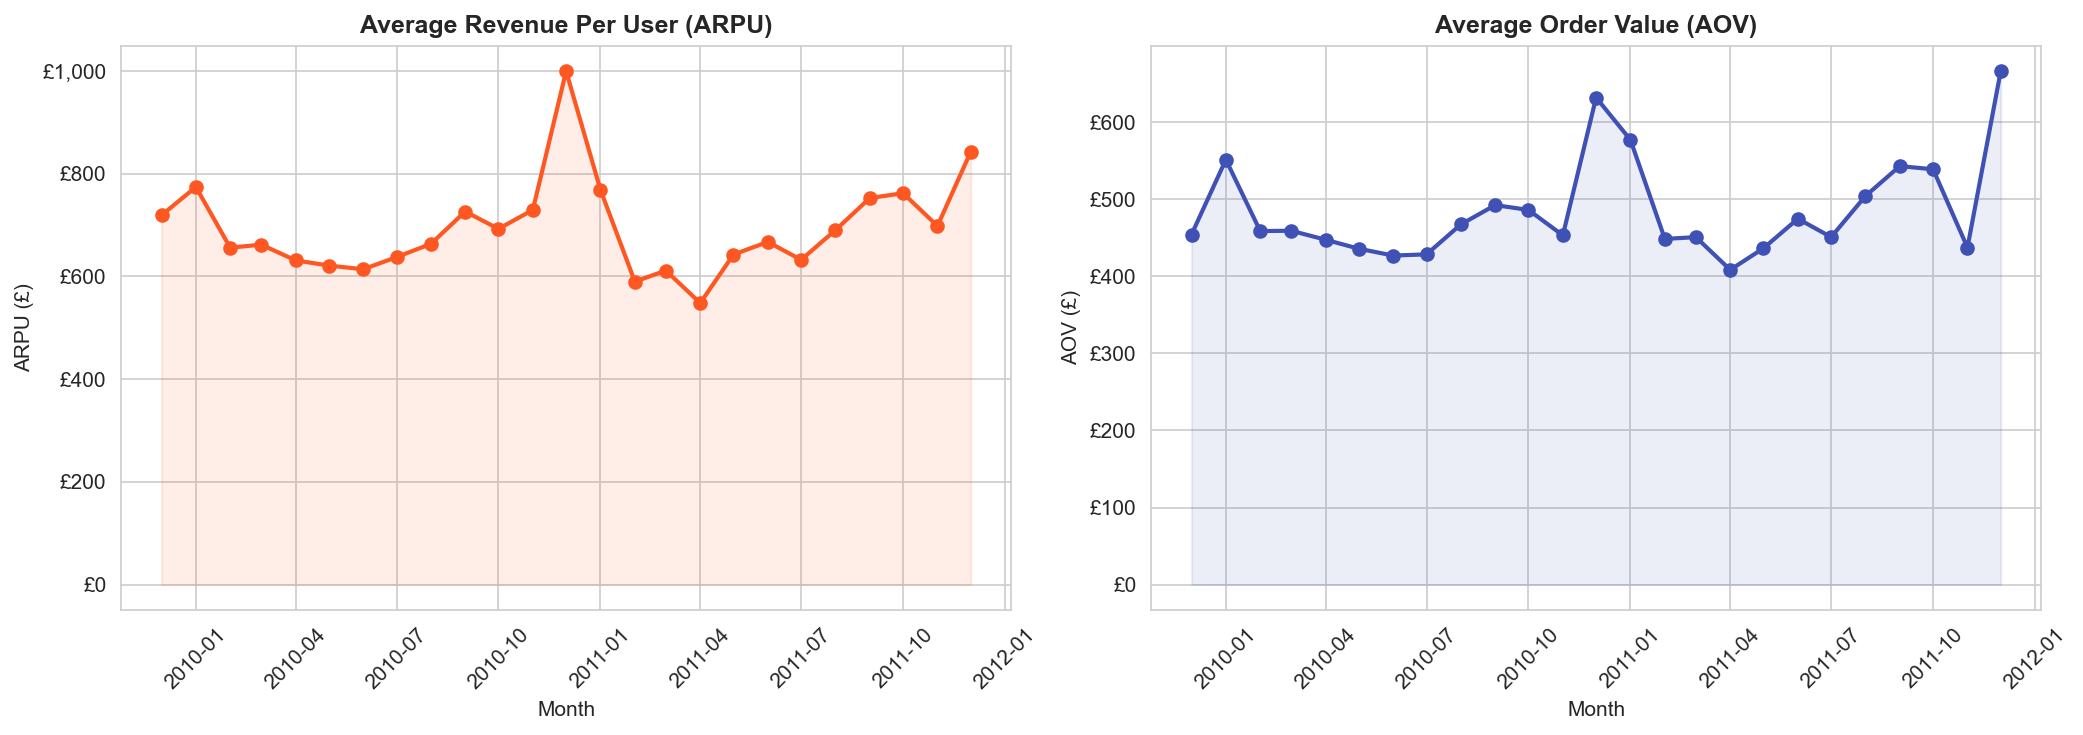

Overall ARPU: £3,018.62
Overall AOV: £479.95


In [19]:
monthly_stats = df.groupby('InvoiceYearMonth').agg(
    total_revenue=('Revenue', 'sum'),
    n_customers=('Customer ID', 'nunique'),
    n_orders=('Invoice', 'nunique')
).reset_index()

monthly_stats['ARPU'] = monthly_stats['total_revenue'] / monthly_stats['n_customers']
monthly_stats['AOV'] = monthly_stats['total_revenue'] / monthly_stats['n_orders']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ARPU
ax1.plot(monthly_stats['InvoiceYearMonth'], monthly_stats['ARPU'], marker='o', color='#FF5722', linewidth=2)
ax1.fill_between(monthly_stats['InvoiceYearMonth'], monthly_stats['ARPU'], alpha=0.1, color='#FF5722')
ax1.set_title('Average Revenue Per User (ARPU)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('ARPU (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.tick_params(axis='x', rotation=45)

# AOV
ax2.plot(monthly_stats['InvoiceYearMonth'], monthly_stats['AOV'], marker='o', color='#3F51B5', linewidth=2)
ax2.fill_between(monthly_stats['InvoiceYearMonth'], monthly_stats['AOV'], alpha=0.1, color='#3F51B5')
ax2.set_title('Average Order Value (AOV)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('AOV (£)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '11_arpu_aov.png', bbox_inches='tight')
plt.show()

print(f'Overall ARPU: £{df["Revenue"].sum() / df["Customer ID"].nunique():,.2f}')
print(f'Overall AOV: £{df["Revenue"].sum() / df["Invoice"].nunique():,.2f}')

### 5.5 Referral — Limitations

**Note**: This dataset does not contain referral/channel attribution data. Referral metrics cannot be directly measured. As a proxy, we can observe the geographic spread of customers, which may loosely indicate word-of-mouth across markets.

In [20]:
country_customers = df.groupby('Country')['Customer ID'].nunique().sort_values(ascending=False)
print(f'Total countries with customers: {len(country_customers)}')
print(f'\nTop 10 countries by customer count:')
for country, count in country_customers.head(10).items():
    print(f'  {country:30s}: {count:,} customers')

Total countries with customers: 41

Top 10 countries by customer count:
  United Kingdom                : 5,350 customers
  Germany                       : 107 customers
  France                        : 95 customers
  Spain                         : 41 customers
  Belgium                       : 29 customers
  Portugal                      : 24 customers
  Switzerland                   : 22 customers
  Netherlands                   : 22 customers
  Sweden                        : 19 customers
  Italy                         : 17 customers


---
## 6. Key Insights & Recommendations

In [21]:
# Gather key metrics for insights
total_customers = df['Customer ID'].nunique()
total_revenue = df['Revenue'].sum()
repeat_buyer_rate = (cust['n_orders'] >= 2).mean()
one_time_pct = (cust['n_orders'] == 1).mean()
uk_share = country_revenue['United Kingdom'] / country_revenue.sum()
month1_retention = avg_retention.iloc[1] if len(avg_retention) > 1 else 0
top_pct_80_rev = pct_80

print('=' * 70)
print('KEY INSIGHTS')
print('=' * 70)

print(f'''
1. HIGH CUSTOMER CONCENTRATION RISK
   Top {top_pct_80_rev:.0f}% of customers generate 80% of revenue (£{total_revenue:,.0f} total).
   Business is heavily dependent on a small customer base.

2. ONE-TIME BUYER PROBLEM
   {one_time_pct:.1%} of customers make only 1 purchase.
   Repeat buyer rate is {repeat_buyer_rate:.1%} — significant room for improvement.

3. STEEP RETENTION DROP-OFF
   Average Month-1 retention is only {month1_retention:.1f}%.
   The biggest churn happens in the first month after acquisition.

4. GEOGRAPHIC OVER-DEPENDENCE
   UK accounts for {uk_share:.1%} of total revenue.
   International expansion represents a major growth opportunity.

5. STRONG SEASONAL PATTERN
   Revenue peaks sharply in Q4 (Sep-Nov) driven by holiday shopping.
   Post-holiday retention dip represents a key challenge.
''')

print('=' * 70)
print('BUSINESS RECOMMENDATIONS')
print('=' * 70)

print(f'''
1. REDUCE FIRST-MONTH CHURN
   Implement a post-purchase email sequence (day 7, 14, 30) with personalized
   product recommendations to convert one-time buyers into repeat customers.

2. LOYALTY PROGRAM FOR HIGH-VALUE CUSTOMERS
   Create tiered rewards for the top {top_pct_80_rev:.0f}% revenue-generating
   customers to increase retention and lifetime value.

3. INTERNATIONAL MARKET DEVELOPMENT
   Prioritize top non-UK markets (Netherlands, EIRE, Germany, France)
   with localized marketing and potentially free shipping thresholds.

4. Q1 RETENTION CAMPAIGN
   Launch targeted re-engagement campaigns in January to retain
   holiday-season acquired customers before they churn.
''')

KEY INSIGHTS

1. HIGH CUSTOMER CONCENTRATION RISK
   Top 23% of customers generate 80% of revenue (£17,743,429 total).
   Business is heavily dependent on a small customer base.

2. ONE-TIME BUYER PROBLEM
   27.6% of customers make only 1 purchase.
   Repeat buyer rate is 72.4% — significant room for improvement.

3. STEEP RETENTION DROP-OFF
   Average Month-1 retention is only 21.2%.
   The biggest churn happens in the first month after acquisition.

4. GEOGRAPHIC OVER-DEPENDENCE
   UK accounts for 83.0% of total revenue.
   International expansion represents a major growth opportunity.

5. STRONG SEASONAL PATTERN
   Revenue peaks sharply in Q4 (Sep-Nov) driven by holiday shopping.
   Post-holiday retention dip represents a key challenge.

BUSINESS RECOMMENDATIONS

1. REDUCE FIRST-MONTH CHURN
   Implement a post-purchase email sequence (day 7, 14, 30) with personalized
   product recommendations to convert one-time buyers into repeat customers.

2. LOYALTY PROGRAM FOR HIGH-VALUE CUSTO

### Summary Dashboard

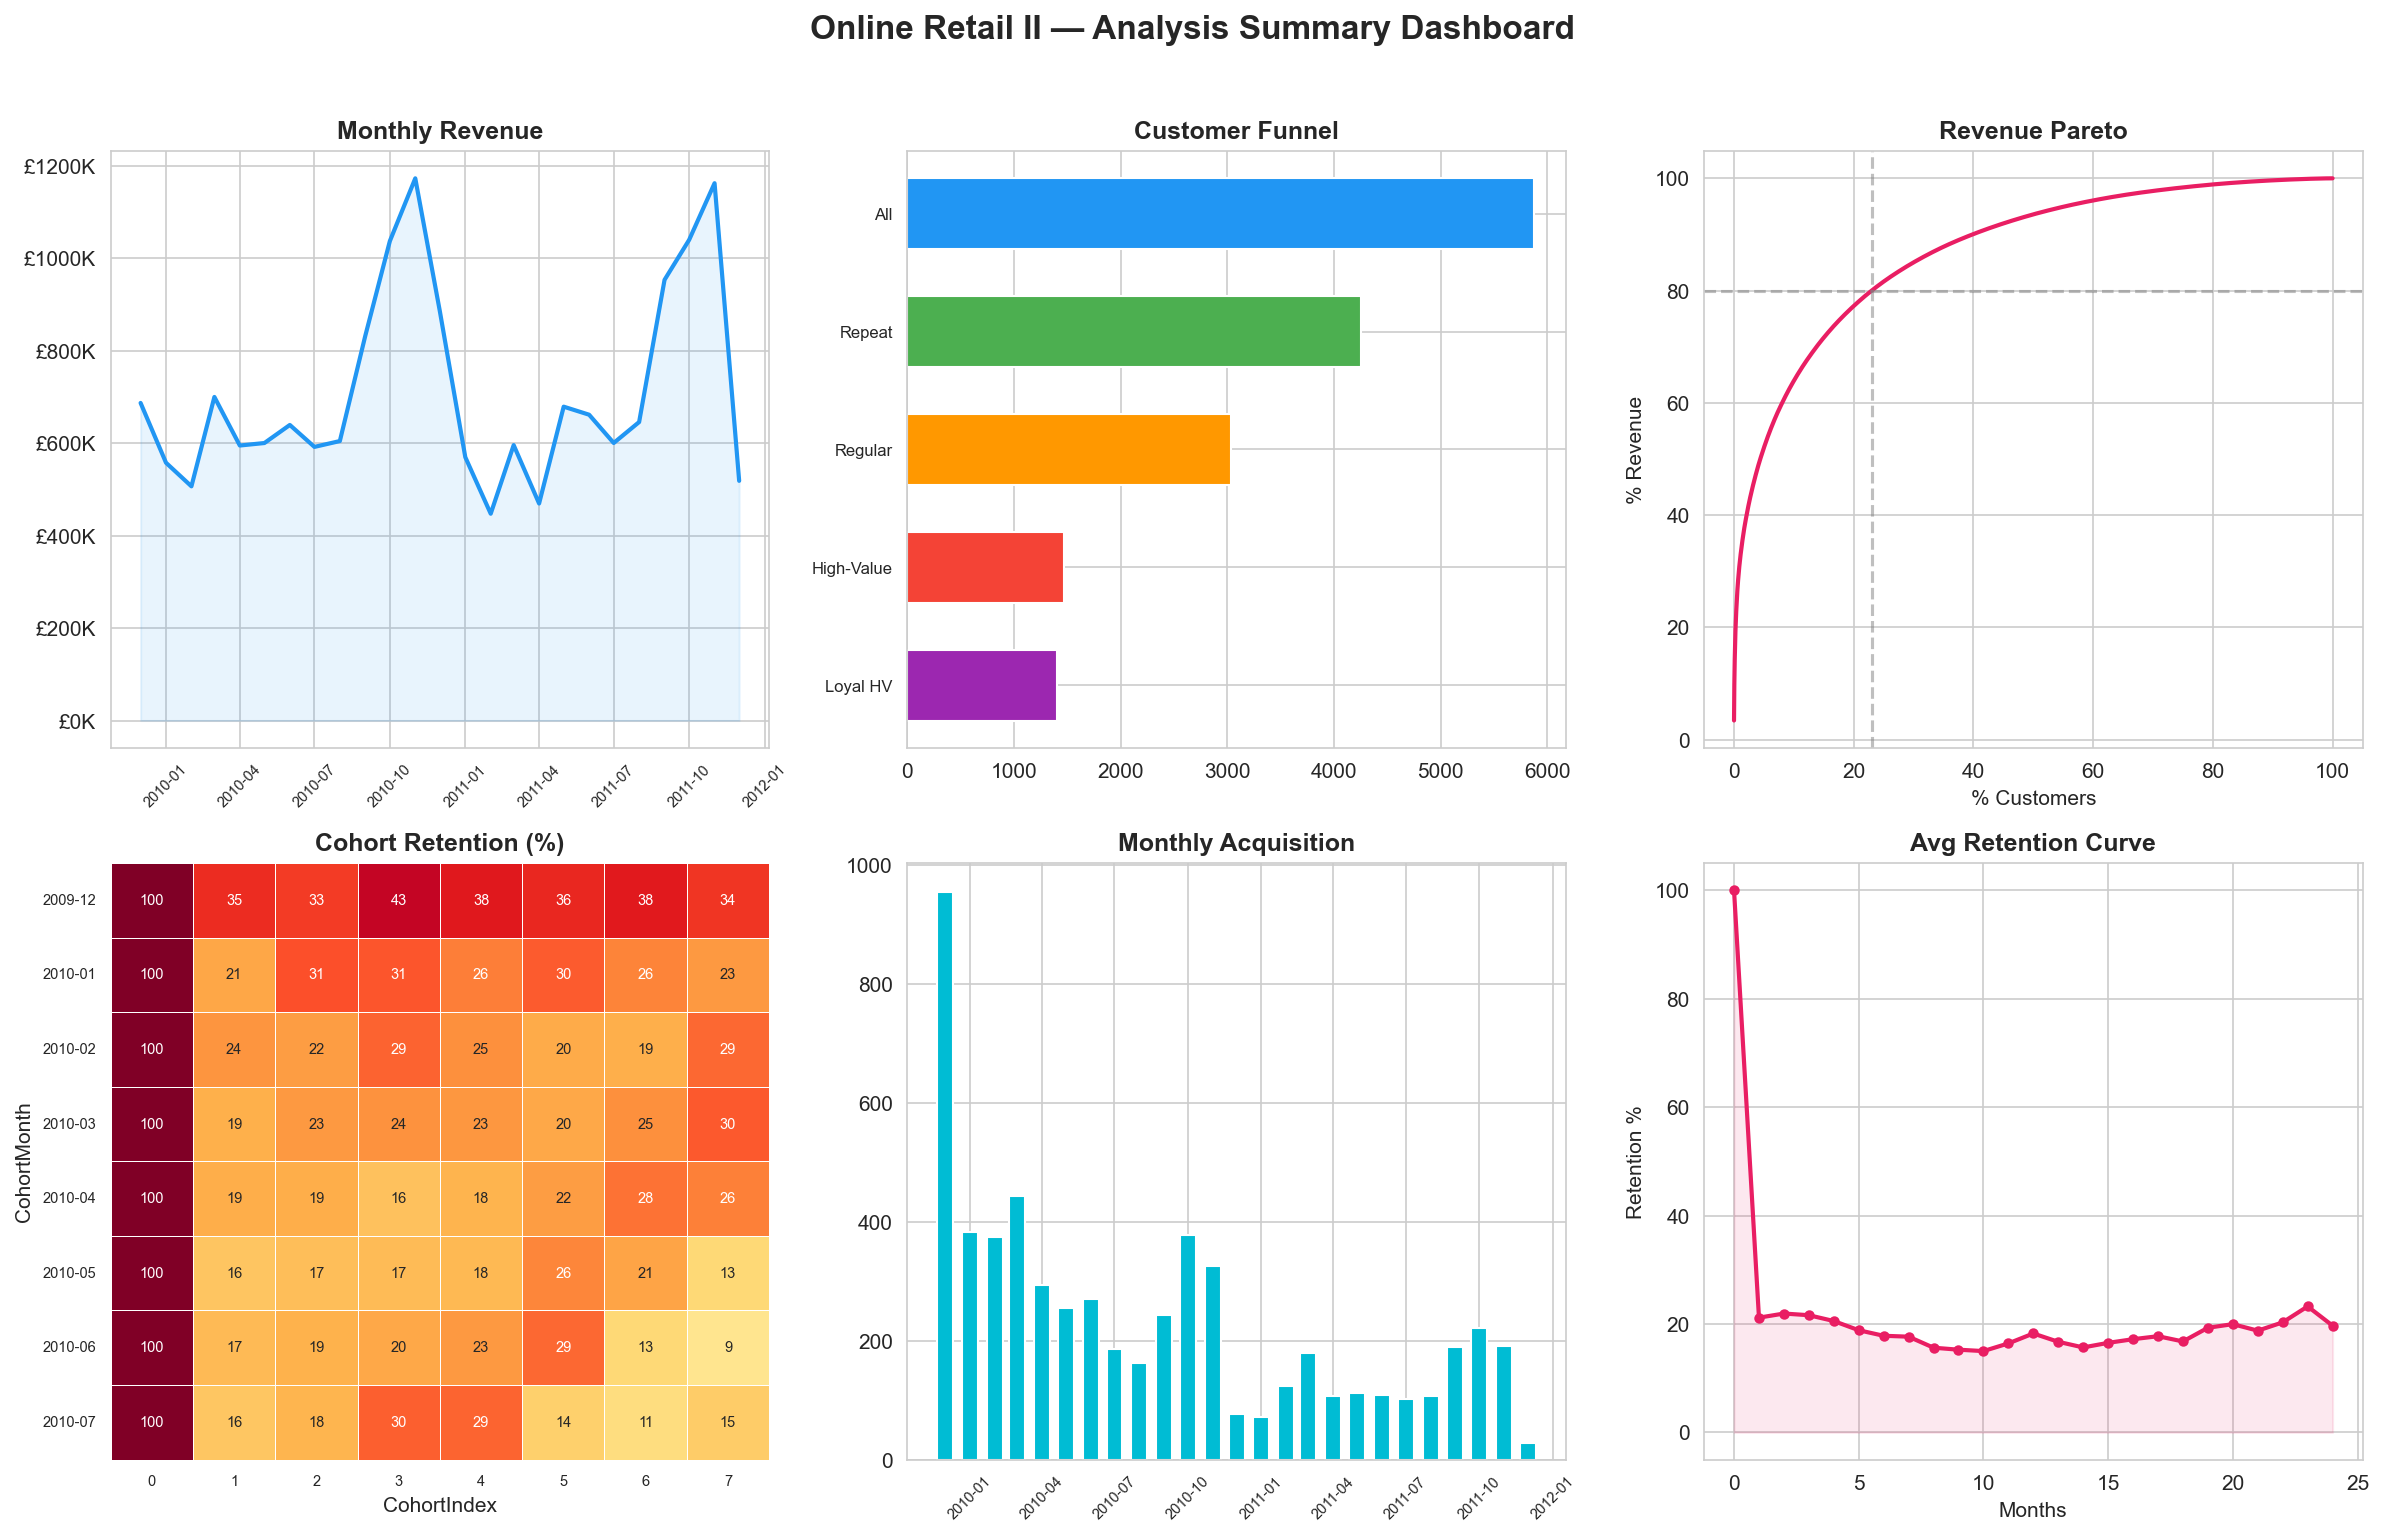

In [22]:
# Create a summary visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Online Retail II — Analysis Summary Dashboard', fontsize=16, fontweight='bold', y=1.02)

# 1. Monthly Revenue
ax = axes[0, 0]
ax.plot(monthly_revenue.index, monthly_revenue.values, color='#2196F3', linewidth=2)
ax.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.1, color='#2196F3')
ax.set_title('Monthly Revenue', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=45, labelsize=7)

# 2. Customer Funnel
ax = axes[0, 1]
colors_f = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
y_f = range(len(funnel_df) - 1, -1, -1)
ax.barh(y_f, funnel_df['Customers'], color=colors_f, height=0.6)
ax.set_yticks(y_f)
short_labels = ['All', 'Repeat', 'Regular', 'High-Value', 'Loyal HV']
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_title('Customer Funnel', fontweight='bold')

# 3. Pareto
ax = axes[0, 2]
ax.plot(customer_pct, cumulative_pct.values, color='#E91E63', linewidth=2)
ax.axhline(80, color='gray', linestyle='--', alpha=0.5)
ax.axvline(pct_80, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Revenue Pareto', fontweight='bold')
ax.set_xlabel('% Customers')
ax.set_ylabel('% Revenue')

# 4. Cohort Heatmap (simplified)
ax = axes[1, 0]
retention_small = retention_display.iloc[:8, :8]
sns.heatmap(retention_small, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, vmin=0, vmax=50, cbar=False,
            annot_kws={'size': 7})
ax.set_title('Cohort Retention (%)', fontweight='bold')
ax.tick_params(axis='both', labelsize=7)

# 5. Acquisition
ax = axes[1, 1]
ax.bar(new_customers.index, new_customers.values, color='#00BCD4', width=20)
ax.set_title('Monthly Acquisition', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)

# 6. Avg Retention Curve
ax = axes[1, 2]
ax.plot(avg_retention.index, avg_retention.values, marker='o', color='#E91E63', linewidth=2, markersize=4)
ax.fill_between(avg_retention.index, avg_retention.values, alpha=0.1, color='#E91E63')
ax.set_title('Avg Retention Curve', fontweight='bold')
ax.set_xlabel('Months')
ax.set_ylabel('Retention %')

plt.tight_layout()
plt.savefig(IMAGES_DIR / '12_summary_dashboard.png', bbox_inches='tight')
plt.show()